<a href="https://colab.research.google.com/github/himanshu1kk/myrepo/blob/main/potatao%20diesease%20clasification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
print("Current working directory:", os.getcwd())

Current working directory: /content


In [9]:
print("Files in /content:", os.listdir('/content'))

Files in /content: ['.config', 'Potatohealthy.zip', 'potato_diseases', 'drive', 'Potato___Late_blight.zip', 'Potato___Early_blight.zip', 'sample_data']


In [3]:
print("hello")

hello


In [4]:
os.makedirs('potato_diseases', exist_ok=True)

In [12]:
!file /content/Potato___Early_blight.zip


/content/Potato___Early_blight.zip: Zip archive data, at least v2.0 to extract, compression method=store


In [13]:
!unzip /content/Potato___Early_blight.zip -d /content/potato_diseases/Early_blight

# !unzip -q /content/Potato___Late_blight.zip -d potato_diseases/Late_blight
# !unzip -q /content/Potatohealthy.zip -d potato_diseases/Healthy

# Verify
print("Extracted folders:", os.listdir('potato_diseases'))

Archive:  /content/Potato___Early_blight.zip
   creating: /content/potato_diseases/Early_blight/Potato___Early_blight/
  inflating: /content/potato_diseases/Early_blight/Potato___Early_blight/001187a0-57ab-4329-baff-e7246a9edeb0___RS_Early.B 8178.JPG  
  inflating: /content/potato_diseases/Early_blight/Potato___Early_blight/002a55fb-7a3d-4a3a-aca8-ce2d5ebc6925___RS_Early.B 8170.JPG  
  inflating: /content/potato_diseases/Early_blight/Potato___Early_blight/009c8c31-f22d-4ffd-8f16-189c6f06c577___RS_Early.B 7885.JPG  
  inflating: /content/potato_diseases/Early_blight/Potato___Early_blight/00d8f10f-5038-4e0f-bb58-0b885ddc0cc5___RS_Early.B 8722.JPG  
  inflating: /content/potato_diseases/Early_blight/Potato___Early_blight/0182e991-97f0-4805-a1f7-6e1b4306d518___RS_Early.B 7015.JPG  
  inflating: /content/potato_diseases/Early_blight/Potato___Early_blight/02578b86-b234-4ac0-9bc3-691b5610e2bf___RS_Early.B 7562.JPG  
  inflating: /content/potato_diseases/Early_blight/Potato___Early_blight/0267

In [14]:
!unzip -q /content/Potato___Late_blight.zip -d potato_diseases/Late_blight


In [15]:
!unzip -q /content/Potatohealthy.zip -d potato_diseases/Healthy

In [16]:
potato_dir = '/content/potato_diseases'
if os.path.exists(potato_dir):
    print("Files in potato_diseases:", os.listdir(potato_dir))
else:
  print("not found")

Files in potato_diseases: ['Late_blight', 'Early_blight', 'Healthy']


unzip:  cannot find or open /content/PotatoLate_blight.zip, /content/PotatoLate_blight.zip.zip or /content/PotatoLate_blight.zip.ZIP.


unzip:  cannot find or open /content/Potatohealthy.zip, /content/Potatohealthy.zip.zip or /content/Potatohealthy.zip.ZIP.


In [17]:
import tensorflow as tf
from tensorflow.keras import models,layers
import matplotlib.pyplot as plt

In [18]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/potato_diseases",  # Updated path
    image_size=(256, 256),
    batch_size=32,
    shuffle=True,
    seed=42,
)

Found 2152 files belonging to 3 classes.


In [19]:
class_names = dataset.class_names
class_names

#early_blight = 0
#health = 1
#late_blight = 2

['Early_blight', 'Healthy', 'Late_blight']

In [20]:
a = 2152/32
a

67.25

In [21]:
len(dataset) #this is because the each dataset has a batch size of 32 so their will be total of 68 batches each of batch size 32 ..1 batch has 32 images

68

In [22]:
for image_batch,labels_batch in dataset.take(1):
  print(image_batch.shape)
  print(labels_batch.numpy())

(32, 256, 256, 3)
[2 2 2 2 2 0 0 2 2 2 1 0 0 1 2 0 0 2 0 0 2 0 0 0 2 0 0 2 0 2 2 0]


Label: Late_blight


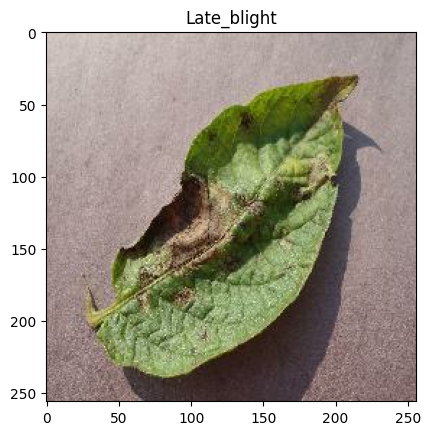

In [23]:
for image_batch,labels_batch in dataset.take(1):
  plt.imshow(image_batch[0].numpy().astype("uint8"))
  plt.title(class_names[labels_batch[0]])
  print("Label:",class_names[labels_batch[0]])


In [24]:
train_size  =0.8

train_ds = dataset.take(54)

len(train_ds)




54

In [25]:
test_ds = dataset.skip(54)
len(test_ds)


14

In [26]:
val_ds = test_ds.take(6)
len(val_ds)

6

In [27]:
test_ds = test_ds.skip(6)
len(test_ds)

8

In [28]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)


In [29]:
resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(256, 256),  # Fixed! No "experimental"
    layers.Rescaling(1.0/255)
])

In [108]:
data_augumentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2)
])

In [109]:
#Now we will use CNN for training the images
model = models.Sequential([
    resize_and_rescale,
    data_augumentation,
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(256, 256, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', input_shape=(256, 256, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', input_shape=(256, 256, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', input_shape=(256, 256, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', input_shape=(256, 256, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', input_shape=(256, 256, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(3, activation='softmax')


])

model.build(input_shape=(32,256, 256, 3))



In [110]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_5 (Sequential)       │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (32, 254, 254, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (32, 127, 127, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (32, 125, 125, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (32, 62, 62, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (32, 60, 60, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (32, 30, 30, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (32, 28, 28, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (32, 14, 14, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (32, 12, 12, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (32, 6, 6, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (32, 4, 4, 64)         │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (32, 2, 2, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (32, 256)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (32, 64)               │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (32, 3)                │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,747 (717.76 KB)

 Trainable params: 183,747 (717.76 KB)

 Non-trainable params: 0 (0.00 B)

In [111]:
model.compile(
    optimizer = 'adam',
    loss= tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [112]:
history = model.fit(
    train_ds,
    epochs = 15,
    batch_size = 32,
    validation_data = val_ds
)

Epoch 1/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - accuracy: 0.4885 - loss: 0.9317 - val_accuracy: 0.5312 - val_loss: 0.8254
Epoch 2/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.6912 - loss: 0.6760 - val_accuracy: 0.7865 - val_loss: 0.4698
Epoch 3/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - accuracy: 0.8680 - loss: 0.3330 - val_accuracy: 0.7708 - val_loss: 0.5742
Epoch 4/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.9014 - loss: 0.2105 - val_accuracy: 0.8177 - val_loss: 0.4318
Epoch 5/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.9434 - loss: 0.1495 - val_accuracy: 0.9740 - val_loss: 0.0865
Epoch 6/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - accuracy: 0.9596 - loss: 0.1269 - val_accuracy: 0.9375 - val_loss: 0.1391
Epoch 7/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.9553 - loss: 0.1132 - val_accuracy: 0.8906 - val_loss: 0.2651
Epoch 8/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.9723 - loss: 0.0914 - val_accuracy: 0.9271 - v

In [113]:
scores = model.evaluate(test_ds)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9082 - loss: 0.3728


In [114]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [115]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.11/dist-packages/matplotlib/pyplot.py'>

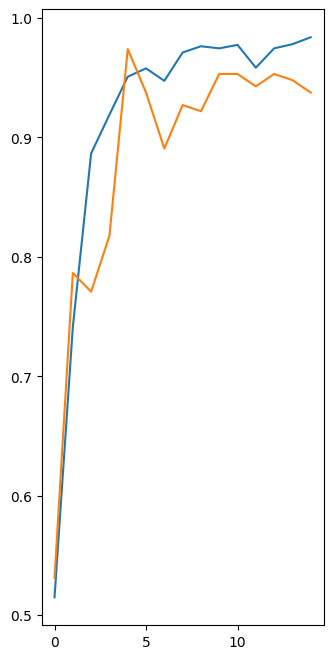

In [116]:
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(range(15), acc, label='Training Accuracy')
plt.plot(range(15), val_acc, label='Validation Accuracy')
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.11/dist-packages/matplotlib/pyplot.py'>

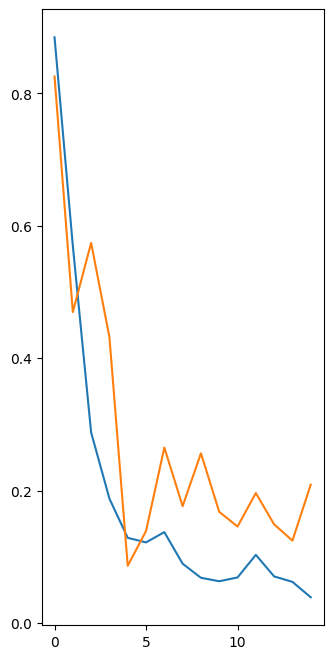

In [117]:
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(range(15), loss, label='Training Loss')
plt.plot(range(15), val_loss, label='Validation Loss')
plt

first image to predict
actual label: Early_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
prediction label :  Early_blight


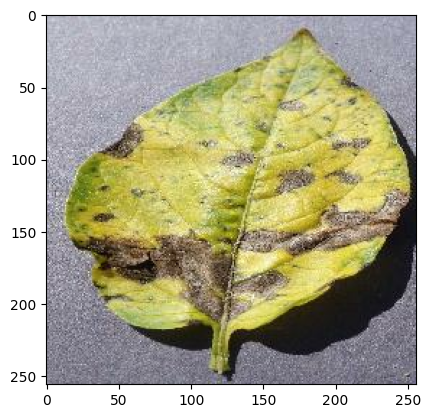

In [120]:
import numpy as np
for images_batch , labels_batch in test_ds.take(1):
  first_image = images_batch[0].numpy().astype('uint8')
  first_label = labels_batch[0].numpy()

  print("first image to predict")
  plt.imshow(first_image)
  print("actual label:",class_names[first_label])

  batch_prediction = model.predict(images_batch)

  print("prediction label : ", class_names[np.argmax(batch_prediction[0])])

In [121]:
export_path = '/content/exported_model'

In [122]:
os.makedirs(export_path, exist_ok=True)

In [123]:
model.save('/content/exported_model.keras')

In [124]:
print("Loading model...")
model = tf.keras.models.load_model('/content/exported_model.keras')

Loading model...


In [101]:
!pip install nest_asyncio

In [125]:
import tensorflow as tf
from fastapi import FastAPI, File, UploadFile, HTTPException
from fastapi.middleware.cors import CORSMiddleware
from fastapi.responses import JSONResponse
from PIL import Image
import numpy as np
from io import BytesIO
import uvicorn
from pyngrok import ngrok
import nest_asyncio
import os

# Apply nest_asyncio patch for Colab
nest_asyncio.apply()

# Set your ngrok authtoken
ngrok.set_auth_token("2yDh9lkKOKekkoccoYtHHapkAPr_7CGGyznnbvEM91UNd1jnP")

# Load the model
model_path = '/content/exported_model.keras'
class_names = ['Early_blight', 'Healthy', 'Late_blight']

try:
    model = tf.keras.models.load_model(model_path)
    print(" Model loaded successfully!")
    print(model.summary())
except Exception as e:
    print(f" Error loading model: {e}")
    raise

# FastAPI setup
app = FastAPI(title="Potato Disease Classifier")

# CORS middleware
app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_methods=["*"],
    allow_headers=["*"],
)

def preprocess_image(image):
    """
    Preprocess the image to match model's expected input
    """
    # Convert to RGB if not already
    if image.mode != 'RGB':
        image = image.convert('RGB')

    img_array = np.array(image)

    img_array = np.expand_dims(img_array, axis=0)

    return img_array

@app.post("/predict/")
async def predict(file: UploadFile = File(...)):
    try:
        contents = await file.read()
        image = Image.open(BytesIO(contents))

        img_array = preprocess_image(image)

        preds = model.predict(img_array)
        pred_class = class_names[np.argmax(preds[0])]
        confidence = float(np.max(preds[0]))

        return JSONResponse({
            "predicted_class": pred_class,
            "confidence": confidence,
            "class_probabilities": {
                class_names[i]: float(preds[0][i])
                for i in range(len(class_names))
            }
        })

    except Exception as e:
        raise HTTPException(status_code=400, detail=str(e))

@app.get("/")
async def root():
    return {"message": "Potato Disease Classification API"}

@app.get("/health")
async def health_check():
    return {"status": "healthy"}

public_url = ngrok.connect(8000).public_url
print(f"🌐 Public URL: {public_url}")

# Start FastAPI server
uvicorn.run(app, host="0.0.0.0", port=8000)

✅ Model loaded successfully!


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_5 (Sequential)       │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (32, 254, 254, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (32, 127, 127, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (32, 125, 125, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (32, 62, 62, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (32, 60, 60, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (32, 30, 30, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (32, 28, 28, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (32, 14, 14, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (32, 12, 12, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (32, 6, 6, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (32, 4, 4, 64)         │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (32, 2, 2, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (32, 256)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (32, 64)               │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (32, 3)                │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 551,243 (2.10 MB)

 Trainable params: 183,747 (717.76 KB)

...

INFO:     Started server process [985]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step
INFO:     2401:4900:866c:ff1d:98f4:1739:e4e4:35cd:0 - "POST /predict/ HTTP/1.1" 200 OK


ERROR:asyncio:Task exception was never retrieved
future: <Task finished name='Task-32' coro=<Server.serve() done, defined at /usr/local/lib/python3.11/dist-packages/uvicorn/server.py:68> exception=KeyboardInterrupt()>
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/uvicorn/main.py", line 580, in run
    server.run()
  File "/usr/local/lib/python3.11/dist-packages/uvicorn/server.py", line 66, in run
    return asyncio.run(self.serve(sockets=sockets))
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/nest_asyncio.py", line 30, in run
    return loop.run_until_complete(task)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/nest_asyncio.py", line 92, in run_until_complete
    self._run_once()
  File "/usr/local/lib/python3.11/dist-packages/nest_asyncio.py", line 133, in _run_once
    handle._run()
  File "/usr/lib/python3.11/asyncio/events.py", line 84, in _run
    s

1/1 ━━━━━━━━━━━━━━━━━━━━ 52s 52s/step
INFO:     2401:4900:866c:ff1d:98f4:1739:e4e4:35cd:0 - "POST /predict/ HTTP/1.1" 200 OK
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
INFO:     2401:4900:866c:ff1d:98f4:1739:e4e4:35cd:0 - "POST /predict/ HTTP/1.1" 200 OK
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
INFO:     2401:4900:866c:ff1d:98f4:1739:e4e4:35cd:0 - "POST /predict/ HTTP/1.1" 200 OK


INFO:     Shutting down
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.
INFO:     Finished server process [985]
